In [3]:
!pip install scikit-learn scipy

In [12]:
# -*- coding: shift_jis -*-
from platform import java_ver
from sklearn.datasets import load_wine
import numpy as np

# ワインデータセットのロード
wine = load_wine()

# データとターゲットの取得
X = wine.data.T  # 特徴量データ
y = wine.target  # ラベルデータ
n,m = X.shape

# 特徴量名とターゲット名の取得
feature_names = wine.feature_names
target_names = wine.target_names

mu = np.mean(X,axis=1)
cov = np.cov(X)

value, vector = np.linalg.eig(cov)

arg = np.argsort(value)[::-1]
value = value[arg]
vector = vector[:,arg]

X_pca = []
for i in range(n):
    tmp = []
    for j in range(n):
        if i==j:
            tmp.append(np.sqrt(value[i]))
        else:
            tmp.append(0)
    X_pca.append(tmp)

data_pca = []
for i in range(n):
    tmp = []
    for j in range(m):
        tmp.append(X[i][j] - mu[i])
    data_pca.append(tmp)

data_pca = np.dot(vector.T, data_pca)
data_pca = np.dot(np.linalg.inv(X_pca), data_pca)

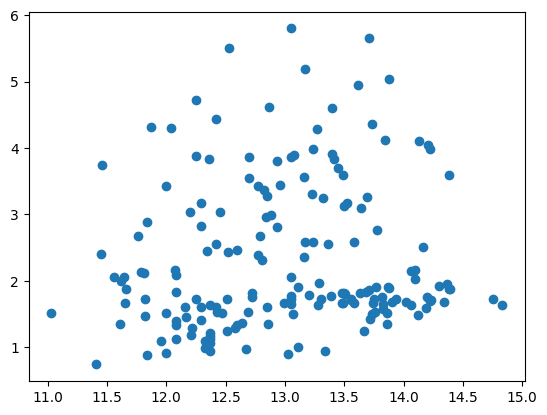

In [13]:
import matplotlib.pyplot as plt
plt.scatter(X[0,:], X[1,:])

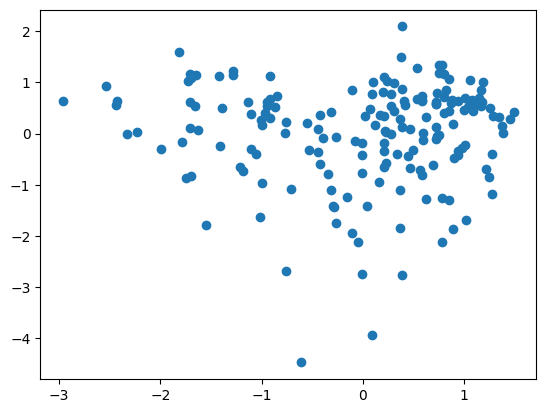

In [14]:
plt.scatter(data_pca[0,:], data_pca[1,:])